In [1]:
from classifier import *
import pandas as pd
import warnings
warnings.filterwarnings("ignore") # suppress all warnings

In [2]:
generate_embeddings("data", "wav2vec2base")

Processing WAV files:   0%|                             | 0/762 [00:00<?, ?it/s]Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Generating embeddings layer-wise: 100%|████████| 13/13 [00:00<00:00, 215.87it/s]


In [3]:
wav2vec2base_df = classify_phonation_mode("wav2vec2base")
wav2vec2base_df.to_csv('results/wav2vec2base_df_mean_embd.csv', index=False)

Layer-wise classification: 100%|████████████████| 13/13 [00:01<00:00,  6.87it/s]


# SVM

## Stratified K-Fold Cross Validation

In [4]:
wav2vec2base_5fold_df, confusion_matrices = k_fold_cross_val("wav2vec2base")
wav2vec2base_5fold_df.to_csv('results/wav2vec2base_5fold_df_mean_embd.csv', index=False)

Layer-wise classification: 100%|████████████████| 13/13 [00:10<00:00,  1.21it/s]


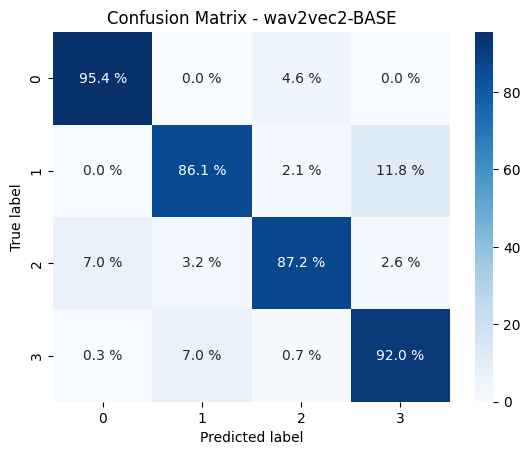

In [5]:
layer_num=0
combined_cm = None
for layer, fold, cm in confusion_matrices:
    if layer_num is None or layer == layer_num:
        if combined_cm is None:
            combined_cm = cm
        else:
            combined_cm += cm

if combined_cm is not None:
    # Calculate percentages
    cm_sum = np.sum(combined_cm, axis=1, keepdims=True)
    combined_cm_percentage = np.round(100 * combined_cm / cm_sum, 2)

    plt.figure()
    plot = sns.heatmap(combined_cm_percentage, annot=True, fmt='.1f', cmap='Blues')
    for t in plot.texts: t.set_text(t.get_text() + " %")
    plt.title(f'Confusion Matrix - wav2vec2-BASE')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

## Hyper-parameter Tuning

In [6]:
model_name = "wav2vec2base"
layer=0
param_grid = {
    'C': [0.001, 0.01, 0.1],
    'gamma': [0.0000001, 0.000001, 0.00001, 0.0001, 0.0001, 0.001, 'scale'],
}

# Perform hyperparameter tuning
best_params, best_score = svm_hyperparameter_tuning(model_name, layer, param_grid)

print("Best hyperparameters:", best_params)
print("Best cross-validation score:", best_score)

Best hyperparameters: {'C': 0.1, 'gamma': 1e-07}
Best cross-validation score: 0.8425438596491228


# Neural Net

In [7]:
wav2vec2base_5fold_nn_df = k_fold_cross_val_nn("wav2vec2base")
wav2vec2base_5fold_nn_df.to_csv('results/wav2vec2base_5fold_nn_df_mean_embd.csv', index=False)

Layer-wise classification: 100%|████████████████| 13/13 [00:33<00:00,  2.59s/it]


# XGB

In [8]:
wav2vec2base_5fold_xgb_df = k_fold_cross_val_xgb("wav2vec2base")
wav2vec2base_5fold_xgb_df.to_csv('results/wav2vec2base_5fold_xgb_df_mean_embd.csv', index=False)

Layer-wise classification: 100%|████████████████| 13/13 [04:24<00:00, 20.31s/it]
